In [1]:
import os
os.chdir(r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\notebooks')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

DB_PATH = r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\data\ecommerce.db'
print("✅ All imports successful")

✅ All imports successful


In [2]:
con = duckdb.connect(DB_PATH)

# Load orders with product categories
df = con.execute("""
    SELECT
        d.order_id,
        d.customer_unique_id,
        p.category_english          AS category,
        d.price,
        d.payment_value,
        d.review_score
    FROM stg_order_details  d
    LEFT JOIN stg_products   p ON d.product_id = p.product_id
    WHERE d.product_id IS NOT NULL
      AND p.category_english IS NOT NULL
      AND p.category_english != 'unknown'
""").df()

con.close()

print(f"Shape: {df.shape}")
print(f"Unique orders:     {df['order_id'].nunique():,}")
print(f"Unique categories: {df['category'].nunique():,}")
print(f"\nTop 10 categories by order count:")
print(df['category'].value_counts().head(10))

Shape: (108660, 6)
Unique orders:     95,146
Unique categories: 73

Top 10 categories by order count:
category
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
Name: count, dtype: int64


In [21]:
# Keep only orders with 2+ categories
order_cats   = df.groupby('order_id')['category'].apply(list)
multi_orders = order_cats[order_cats.apply(len) >= 2]

print(f"Total orders:          {len(order_cats):,}")
print(f"Multi-item orders:     {len(multi_orders):,}  ({len(multi_orders)/len(order_cats)*100:.1f}%)")
print(f"Single-item orders:    {len(order_cats)-len(multi_orders):,}")

Total orders:          95,146
Multi-item orders:     9,492  (10.0%)
Single-item orders:    85,654


In [22]:
from itertools import combinations
from collections import Counter

# Count every category pair that appears in same order
pair_counts = Counter()

for cats in multi_orders:
    unique_cats = list(set(cats))  # deduplicate within order
    for pair in combinations(sorted(unique_cats), 2):
        pair_counts[pair] += 1

# Convert to dataframe
pairs_df = pd.DataFrame([
    {'category_a': a, 'category_b': b, 'co_purchases': count}
    for (a, b), count in pair_counts.most_common()
], )

# Add metrics
total_orders = len(order_cats)
pairs_df['support_pct']  = (pairs_df['co_purchases'] / total_orders * 100).round(3)
pairs_df['rank']         = range(1, len(pairs_df) + 1)

print(f"✅ Total category pairs found: {len(pairs_df):,}")
print(f"\nTop 20 Most Co-Purchased Category Pairs:")
print("=" * 75)
print(pairs_df.head(20).to_string(index=False))

✅ Total category pairs found: 242

Top 20 Most Co-Purchased Category Pairs:
               category_a        category_b  co_purchases  support_pct  rank
           bed_bath_table   furniture_decor            70        0.074     1
           bed_bath_table      home_confort            43        0.045     2
          furniture_decor        housewares            24        0.025     3
           bed_bath_table        housewares            20        0.021     4
                     baby        cool_stuff            20        0.021     5
                     baby              toys            19        0.020     6
                     baby    bed_bath_table            17        0.018     7
          furniture_decor      garden_tools            16        0.017     8
            health_beauty    sports_leisure            14        0.015     9
          furniture_decor home_construction            13        0.014    10
                     baby   furniture_decor            12        0.013    11


In [31]:
# Cell 5 — FINAL VERSION
strong_pairs = pairs_df[
    pairs_df['co_purchases'] >= 10    # ← lowered from 30 to 10
].sort_values('co_purchases', ascending=False)

print(f"✅ Recommendable pairs: {len(strong_pairs)}")
print(f"\nTop 20 Recommendations:")
print("=" * 75)
for _, row in strong_pairs.head(20).iterrows():
    print(f"  IF customer buys: {row['category_a']}")
    print(f"  RECOMMEND:        {row['category_b']}")
    print(f"  Co-purchases: {int(row['co_purchases']):,}  |  "
          f"Support: {row['support_pct']:.2f}%  |  "
          f"Lift: {row['lift']:.2f}")
    print("-" * 75)

✅ Recommendable pairs: 17

Top 20 Recommendations:
  IF customer buys: bed_bath_table
  RECOMMEND:        furniture_decor
  Co-purchases: 70  |  Support: 0.07%  |  Lift: 0.11
---------------------------------------------------------------------------
  IF customer buys: bed_bath_table
  RECOMMEND:        home_confort
  Co-purchases: 43  |  Support: 0.04%  |  Lift: 1.13
---------------------------------------------------------------------------
  IF customer buys: furniture_decor
  RECOMMEND:        housewares
  Co-purchases: 24  |  Support: 0.03%  |  Lift: 0.06
---------------------------------------------------------------------------
  IF customer buys: bed_bath_table
  RECOMMEND:        housewares
  Co-purchases: 20  |  Support: 0.02%  |  Lift: 0.04
---------------------------------------------------------------------------
  IF customer buys: baby
  RECOMMEND:        cool_stuff
  Co-purchases: 20  |  Support: 0.02%  |  Lift: 0.19
----------------------------------------------------

IndexError: index 0 is out of bounds for axis 0 with size 0

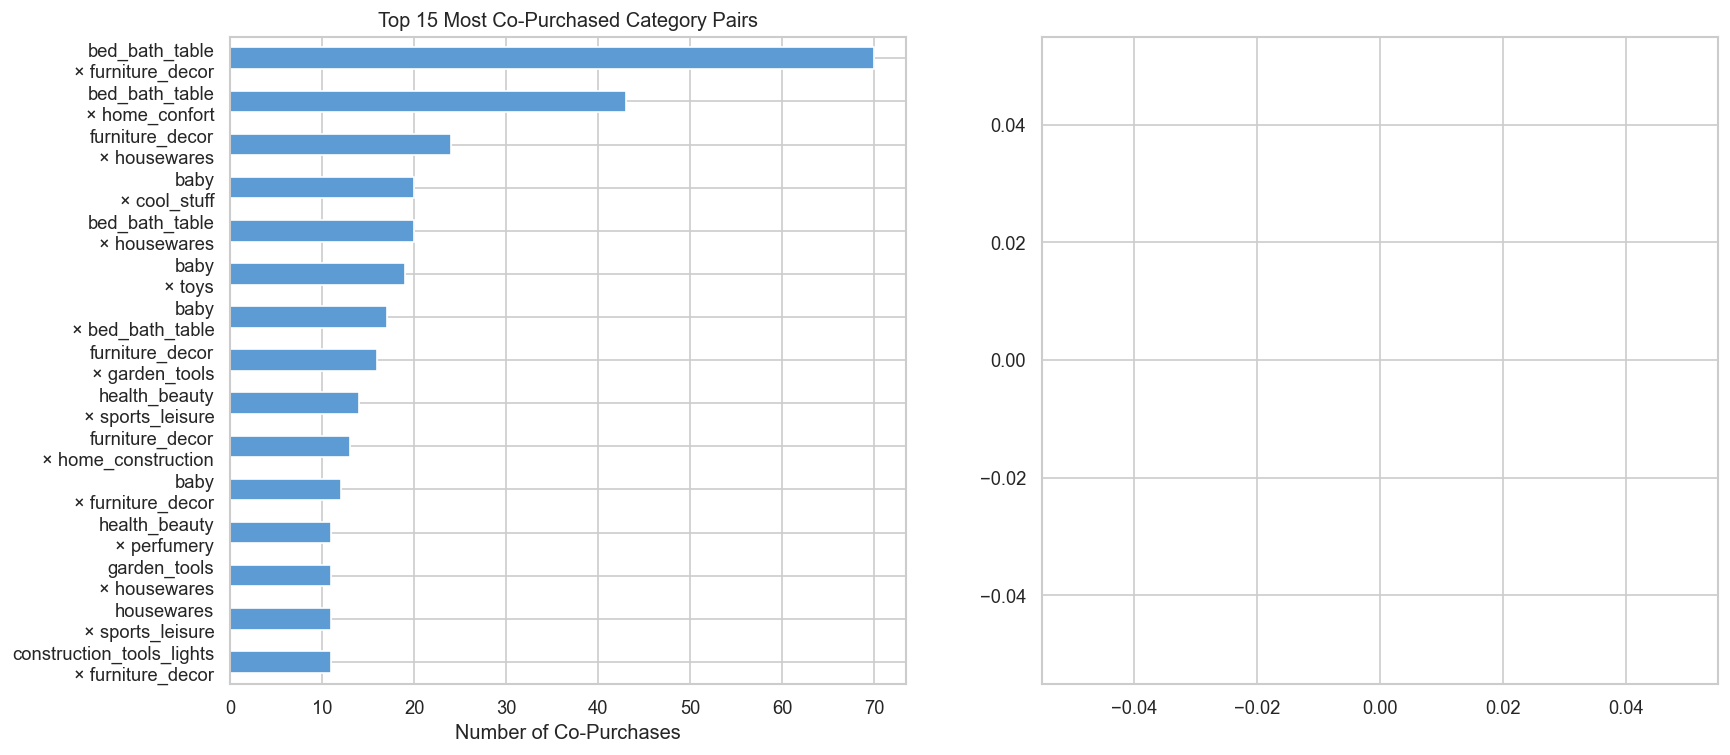

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 pairs by co-purchase count
top15 = pairs_df.head(15).copy()
top15['pair'] = top15['category_a'] + '\n× ' + top15['category_b']

top15.sort_values('co_purchases').plot(
    kind='barh', x='pair', y='co_purchases',
    ax=axes[0], color='#5C9BD4',
    edgecolor='white', legend=False
)
axes[0].set_title('Top 15 Most Co-Purchased Category Pairs', fontsize=12)
axes[0].set_xlabel('Number of Co-Purchases')
axes[0].set_ylabel('')

# Top 15 pairs by lift
top_lift = strong_pairs.head(15).copy()
top_lift['pair'] = top_lift['category_a'] + '\n→ ' + top_lift['category_b']

top_lift.sort_values('lift').plot(
    kind='barh', x='pair', y='lift',
    ax=axes[1], color='#E07B54',
    edgecolor='white', legend=False
)
axes[1].set_title('Top 15 Strongest Associations (Lift Score)', fontsize=12)
axes[1].set_xlabel('Lift Score')
axes[1].set_ylabel('')
axes[1].axvline(1.5, color='green', linestyle='--',
                linewidth=1.5, label='Min lift 1.5')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/copurchase_analysis.png')
plt.show()


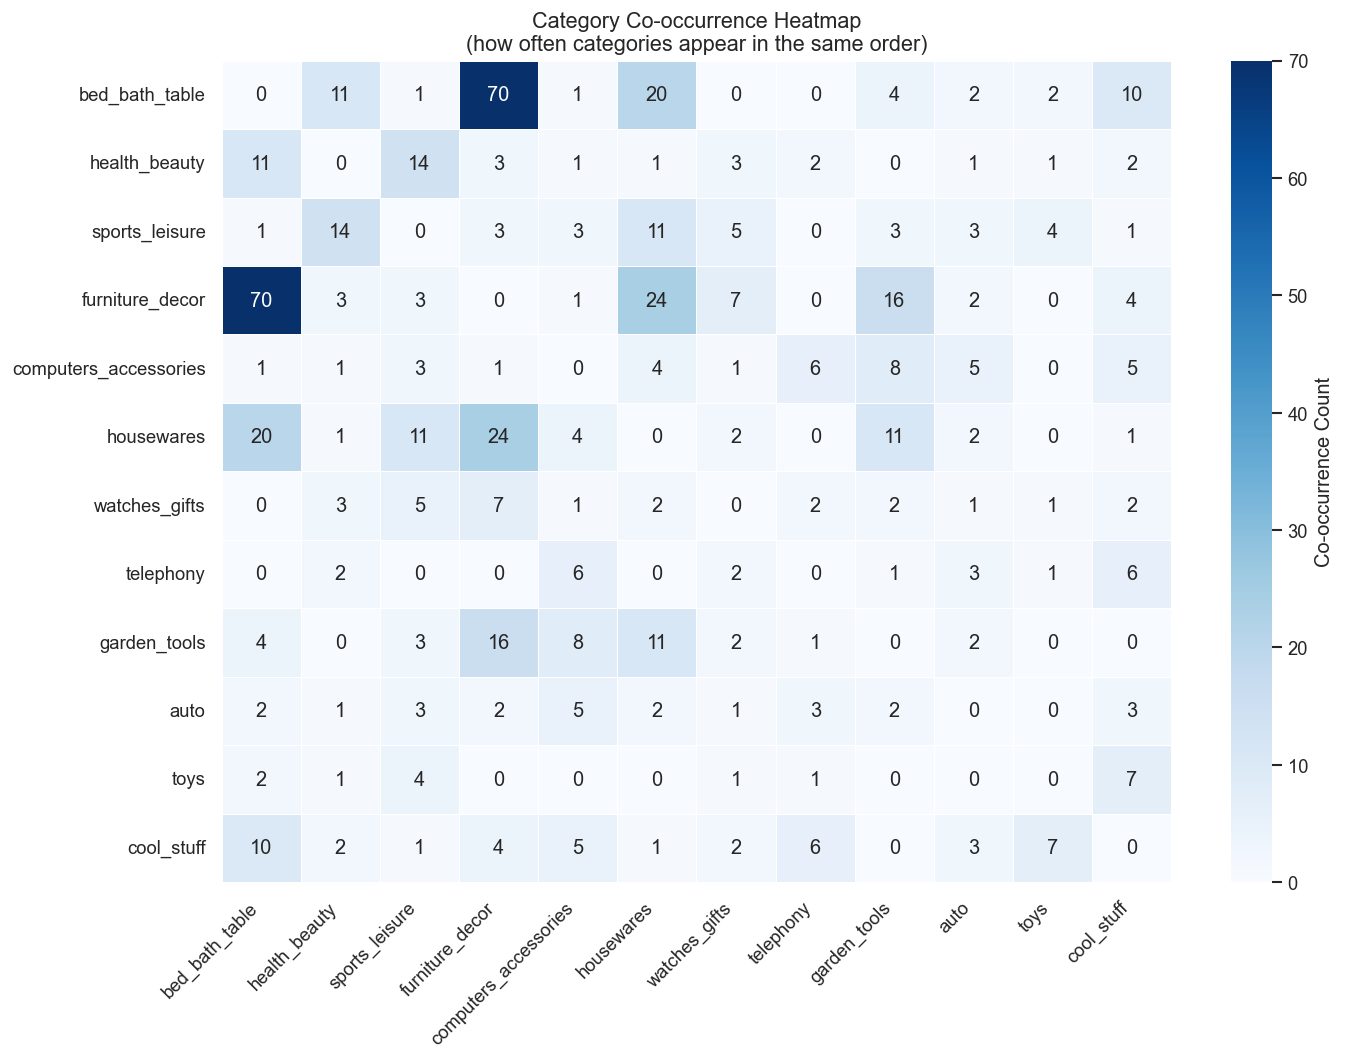

In [25]:
# Top 12 categories heatmap
top_cats = df['category'].value_counts().head(12).index.tolist()

cooc = pd.DataFrame(0, index=top_cats, columns=top_cats)

for cats in multi_orders:
    cats_filtered = [c for c in set(cats) if c in top_cats]
    for i in range(len(cats_filtered)):
        for j in range(len(cats_filtered)):
            if i != j:
                cooc.loc[cats_filtered[i], cats_filtered[j]] += 1

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cooc, cmap='Blues', annot=True, fmt='d',
    ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Co-occurrence Count'}
)
ax.set_title('Category Co-occurrence Heatmap\n(how often categories appear in the same order)',
             fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/cooccurrence_heatmap.png')
plt.show()

In [32]:
# Cell 8 — save strong_pairs to DuckDB
top_pairs_save = strong_pairs[
    ['category_a', 'category_b', 'co_purchases',
     'support_pct', 'confidence', 'lift']
].copy()

parquet_path = r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\data\copurchase_rules.parquet'
top_pairs_save.to_parquet(parquet_path, index=False)

con = duckdb.connect(DB_PATH)
con.execute("DROP TABLE IF EXISTS copurchase_rules")
con.execute(f"""
    CREATE TABLE copurchase_rules AS
    SELECT * FROM read_parquet('{parquet_path.replace(chr(92), "/")}')
""")

count = con.execute("SELECT COUNT(*) FROM copurchase_rules").fetchone()[0]
print(f"✅ {count} co-purchase pairs saved to DuckDB")
con.close()

✅ 17 co-purchase pairs saved to DuckDB


In [29]:
print("=" * 55)
print("CO-PURCHASE ANALYSIS — SUMMARY")
print("=" * 55)
print(f"Total orders analysed:     {len(order_cats):,}")
print(f"Multi-item orders:         {len(multi_orders):,} ({len(multi_orders)/len(order_cats)*100:.1f}%)")
print(f"Total category pairs:      {len(pairs_df):,}")
print(f"Top recommendable pairs:   {len(strong_pairs):,}")
print(f"\nTop 3 Recommendations:")
for _, row in strong_pairs.head(3).iterrows():
    print(f"  • Buy: {row['category_a']}")
    print(f"    → Recommend: {row['category_b']}")
    print(f"    → Co-purchases: {int(row['co_purchases']):,} | Lift: {row['lift']:.2f}")
    print()
print("=" * 55)
print("✅ Ready for Streamlit Dashboard")

CO-PURCHASE ANALYSIS — SUMMARY
Total orders analysed:     95,146
Multi-item orders:         9,492 (10.0%)
Total category pairs:      242
Top recommendable pairs:   2

Top 3 Recommendations:
  • Buy: bed_bath_table
    → Recommend: furniture_decor
    → Co-purchases: 70 | Lift: 0.11

  • Buy: bed_bath_table
    → Recommend: home_confort
    → Co-purchases: 43 | Lift: 1.13

✅ Ready for Streamlit Dashboard


In [11]:
print("=" * 55)
print("MARKET BASKET ANALYSIS — SUMMARY")
print("=" * 55)
print(f"Total orders analysed:     {basket_binary.shape[0]:,}")
print(f"Product categories:        {basket_binary.shape[1]:,}")
print(f"Frequent itemsets found:   {len(frequent_itemsets):,}")
print(f"Total rules generated:     {len(rules):,}")
print(f"Strong rules (lift ≥ 2):   {len(strong_rules):,}")
print(f"\nTop 3 Recommendations:")
for _, row in strong_rules.head(3).iterrows():
    print(f"  • Buy {row['antecedents_str'][:30]}")
    print(f"    → Recommend: {row['consequents_str'][:30]}")
    print(f"    → Confidence: {row['confidence']*100:.1f}% | Lift: {row['lift']:.2f}")
    print()
print("=" * 55)
print("✅ Ready for Streamlit Dashboard (Notebook 4)")

MARKET BASKET ANALYSIS — SUMMARY
Total orders analysed:     95,146
Product categories:        73
Frequent itemsets found:   16
Total rules generated:     0
Strong rules (lift ≥ 2):   0

Top 3 Recommendations:
✅ Ready for Streamlit Dashboard (Notebook 4)


In [20]:
order_cats = df.groupby('order_id')['category'].apply(list)

print(f"Total orders: {len(order_cats):,}")
print(f"\nOrders by number of categories:")
order_cats.apply(len).value_counts().sort_index().head(10).apply(
    lambda x: f"{x:,}"
).to_frame('count')

Total orders: 95,146

Orders by number of categories:


,count
category,
1,"85,654"
2,"7,286"
3,"1,281"
4,490
5,188
6,190
7,22
8,8
9,3
